## Data Profiling

### 1· Imports & Configuration

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path(os.getcwd())

In [2]:
# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
})
PALETTE = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED", "#0891B2"]
# ── Paths ─────────────────────────────────────────────────────────────────────
RAW = Path("../data/raw")
TICKETS_PATH = RAW / "support_tickets_10k.csv"
FAQ_KNOWLEDGE_BASE_PATH = RAW / "faq_knowledge_base_150.csv"
print("✅ Setup complete")

✅ Setup complete


### 2· Helper Functions

In [3]:
def section(title: str) -> None:
    """Print a visible section divider."""
    print(f"\n{'='*60}")
    print(f"  {title}")
    print('='*60)


def quick_profile(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Return a tidy profile DataFrame for a given DataFrame.
    Columns: dtype | non_null | null_count | null_pct | unique | sample_values
    """
    rows = []
    for col in df.columns:
        series = df[col]
        null_count = series.isna().sum()
        rows.append({
            "column"       : col,
            "dtype"        : str(series.dtype),
            "non_null"     : series.notna().sum(),
            "null_count"   : null_count,
            "null_pct"     : round(null_count / len(df) * 100, 2),
            "unique"       : series.nunique(),
            "sample_values": str(series.dropna().unique()[:3].tolist()),
        })
    profile = pd.DataFrame(rows).set_index("column")
    section(f"Profile — {name}  ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    display(profile)
    return profile
def plot_nulls(df: pd.DataFrame, title: str) -> None:
    """Bar chart of null percentages per column (skips cols with 0% nulls)."""
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        print(f"  ✅ No nulls found in {title}")
        return
    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.barh(null_pct.index, null_pct.values, color=PALETTE[2])
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_xlabel("Null %")
    ax.set_title(f"Null % per column — {title}")
    plt.tight_layout()
    plt.show()


print("✅ Helpers defined")

✅ Helpers defined


### 3. Support Tickets(support_tcikets_10k.csv)

#### 3.1. Profile - Support Tickets

In [4]:
tickets = pd.read_csv(TICKETS_PATH)
_ = quick_profile(tickets, "Support Tickets")


  Profile — Support Tickets  (10,000 rows × 15 cols)


,dtype,non_null,null_count,null_pct,unique,sample_values
column,,,,,,
ticket_id,str,10000,0,0.0,10000,"['TKT100000', 'TKT100001', 'TKT100002']"
created_date,str,10000,0,0.0,730,"['2023-08-12', '2023-12-11', '2024-01-06']"
ticket_text,str,10000,0,0.0,8777,['The lipstick I received in order #ORD5614226...
product_name,str,10000,0,0.0,130,"['lipstick', 'shoe rack', 'conditioner']"
product_segment,str,10000,0,0.0,8,"['Beauty & Personal Care', 'Home & Kitchen', '..."
ticket_category,str,10000,0,0.0,7,"['Product Issue', 'Refund & Return', 'Payment ..."
priority,str,10000,0,0.0,3,"['High', 'Low', 'Medium']"
sentiment,str,10000,0,0.0,5,"['Negative', 'Positive', 'Very Negative']"
confidence_score,float64,10000,0,0.0,35,"[0.66, 0.74, 0.93]"


#### 3.2. Duplicate check

In [5]:
section("Duplicate Check — Support Tickets")

# Full-row duplicates
full_dupes = tickets.duplicated().sum()
print(f"Full-row duplicates: {full_dupes}")

# ticket_id should be unique — check separately
id_dupes = tickets['ticket_id'].duplicated().sum()
print(f"Duplicate ticket_id values: {id_dupes}")

# ticket_text duplicates (near-duplicate content, different IDs)
text_dupes = tickets['ticket_text'].duplicated().sum()
print(f"Duplicate ticket_text values: {text_dupes}")
if text_dupes > 0:
    dupe_examples = tickets[tickets['ticket_text'].duplicated(keep=False)].sort_values('ticket_text')
    print(f"\nSample duplicate ticket_text rows:")
    display(dupe_examples[['ticket_id', 'ticket_text', 'ticket_category']].head(10))


  Duplicate Check — Support Tickets
Full-row duplicates: 0
Duplicate ticket_id values: 0
Duplicate ticket_text values: 1223

Sample duplicate ticket_text rows:


,ticket_id,ticket_text,ticket_category
6221,TKT106221,Account is showing a different name than what ...,Account & Login
4624,TKT104624,Account is showing a different name than what ...,Account & Login
1599,TKT101599,Account is showing a different name than what ...,Account & Login
1562,TKT101562,Account is showing a different name than what ...,Account & Login
1543,TKT101543,Account is showing a different name than what ...,Account & Login
1510,TKT101510,Account is showing a different name than what ...,Account & Login
7070,TKT107070,Account is showing a different name than what ...,Account & Login
4905,TKT104905,Account is showing a different name than what ...,Account & Login
1285,TKT101285,Account is showing a different name than what ...,Account & Login
9263,TKT109263,Account is showing a different name than what ...,Account & Login


#### 3.3. Label Consistency Within Duplicated ticket_text

In [6]:
section("Label Consistency Within Duplicated ticket_text")

# For every ticket_text that repeats, check whether sentiment/priority/category
# are stable — i.e. is the label a deterministic function of the text, or is
# there label noise the model can't learn past?
dupe_texts = tickets['ticket_text'].value_counts()
dupe_texts = dupe_texts[dupe_texts > 1].index
subset = tickets[tickets['ticket_text'].isin(dupe_texts)]

label_consistency = subset.groupby('ticket_text').agg(
    n_sentiments=('sentiment', 'nunique'),
    n_priorities=('priority', 'nunique'),
    n_categories=('ticket_category', 'nunique'),
    group_size=('ticket_id', 'count'),
)

print(f"{len(label_consistency)} distinct texts repeat, covering {len(subset)} rows.\n")
for col, label in [('n_sentiments', 'sentiment'), ('n_priorities', 'priority'), ('n_categories', 'ticket_category')]:
    consistent = (label_consistency[col] == 1).sum()
    pct = round(consistent / len(label_consistency) * 100, 1)
    print(f"{label}: consistent in {consistent}/{len(label_consistency)} groups ({pct}%)")

display(label_consistency.sort_values('n_sentiments', ascending=False).head(10))


  Label Consistency Within Duplicated ticket_text
224 distinct texts repeat, covering 1447 rows.

sentiment: consistent in 71/224 groups (31.7%)
priority: consistent in 165/224 groups (73.7%)
ticket_category: consistent in 224/224 groups (100.0%)


,n_sentiments,n_priorities,n_categories,group_size
ticket_text,,,,
Two accounts were created with the same email address. I need them merged.,5,3,1,54
I cannot change my email address. The verification link expires before I can click it.,5,3,1,62
"I received an email saying my account password was changed, but I did not do this.",5,3,1,66
I want to update my mobile number but OTP is not being received on new number.,5,3,1,52
My Business account features were downgraded to personal without any notification.,5,3,1,53
Account is showing a different name than what I registered with. Data integrity issue.,4,3,1,62
My cart items keep disappearing when I switch between the app and website.,4,3,1,70
I am unable to access my saved payment methods. They disappeared after recent login.,4,3,1,54
I can't log into my account. Forgot password and the reset email is not arriving.,4,3,1,49


#### 3.3. Cardinality check

In [7]:
def cardinality_report(df: pd.DataFrame, name: str, high_card_threshold: float = 0.5) -> pd.DataFrame:
    """
    Flags columns as low/medium/high cardinality.
    high_card_threshold: unique/total ratio above which a column is flagged high-cardinality.
    """
    rows = []
    for col in df.columns:
        n_unique = df[col].nunique()
        ratio = n_unique / len(df)
        if ratio > high_card_threshold:
            level = "HIGH (likely free-text/ID)"
        elif n_unique <= 15:
            level = "LOW (categorical)"
        else:
            level = "MEDIUM"
        rows.append({"column": col, "unique": n_unique, "unique_ratio": round(ratio, 3), "cardinality": level})
    report = pd.DataFrame(rows).set_index("column")
    section(f"Cardinality Report — {name}")
    display(report)
    return report

_=cardinality_report(tickets, "Support Tickets")


  Cardinality Report — Support Tickets


,unique,unique_ratio,cardinality
column,,,
ticket_id,10000,1.000,HIGH (likely free-text/ID)
created_date,730,0.073,MEDIUM
ticket_text,8777,0.878,HIGH (likely free-text/ID)
product_name,130,0.013,MEDIUM
product_segment,8,0.001,LOW (categorical)
ticket_category,7,0.001,LOW (categorical)
priority,3,0.000,LOW (categorical)
sentiment,5,0.001,LOW (categorical)
confidence_score,35,0.004,MEDIUM


#### 3.4. Date sanity check:

In [8]:
section("Date Sanity Check — Support Tickets")

tickets['created_date_dt'] = pd.to_datetime(tickets['created_date'], errors='coerce')
tickets['resolved_date_dt'] = pd.to_datetime(tickets['resolved_date'], errors='coerce')

bad_parse = tickets['created_date_dt'].isna().sum() + tickets['resolved_date_dt'].isna().sum()
print(f"Unparseable dates: {bad_parse}")

# resolved_date should never be before created_date
inverted = tickets[tickets['resolved_date_dt'] < tickets['created_date_dt']]
print(f"Rows where resolved_date < created_date: {len(inverted)}")
if len(inverted) > 0:
    display(inverted[['ticket_id', 'created_date', 'resolved_date', 'resolution_days']].head(10))

# resolution_days should match the actual date delta
tickets['computed_resolution_days'] = (tickets['resolved_date_dt'] - tickets['created_date_dt']).dt.days
mismatch = tickets[tickets['computed_resolution_days'] != tickets['resolution_days']]
print(f"Rows where resolution_days column disagrees with computed delta: {len(mismatch)}")
if len(mismatch) > 0:
    display(mismatch[['ticket_id', 'created_date', 'resolved_date', 'resolution_days', 'computed_resolution_days']].head(10))

# Date range sanity
print(f"\ncreated_date range: {tickets['created_date_dt'].min()} → {tickets['created_date_dt'].max()}")
print(f"resolved_date range: {tickets['resolved_date_dt'].min()} → {tickets['resolved_date_dt'].max()}")


  Date Sanity Check — Support Tickets
Unparseable dates: 0
Rows where resolved_date < created_date: 0
Rows where resolution_days column disagrees with computed delta: 0

created_date range: 2023-01-01 00:00:00 → 2024-12-30 00:00:00
resolved_date range: 2023-01-03 00:00:00 → 2025-01-09 00:00:00


#### 3.5. Numeric columns descriptive stats:

In [9]:
# ── Numeric columns descriptive stats ─────────────────────────────────────────
num_cols_tickets = tickets.select_dtypes(include='number').columns.tolist()

print("Numeric columns descriptive stats — Support Tickets:")
display(tickets[num_cols_tickets].describe().T.round(2))

Numeric columns descriptive stats — Support Tickets:


,count,mean,std,min,25%,50%,75%,max
confidence_score,10000.0,0.82,0.10,0.65,0.73,0.82,0.9,0.99
resolution_days,10000.0,4.82,2.62,1.00,3.00,5.00,7.0,10.00
customer_satisfaction_score,10000.0,3.40,1.27,1.00,3.00,4.00,4.0,5.00
computed_resolution_days,10000.0,4.82,2.62,1.00,3.00,5.00,7.0,10.00


#### 3.6. Category distribution:

Detected 7 categorical columns: ['product_name', 'product_segment', 'ticket_category', 'priority', 'sentiment', 'escalated', 'auto_resolved']


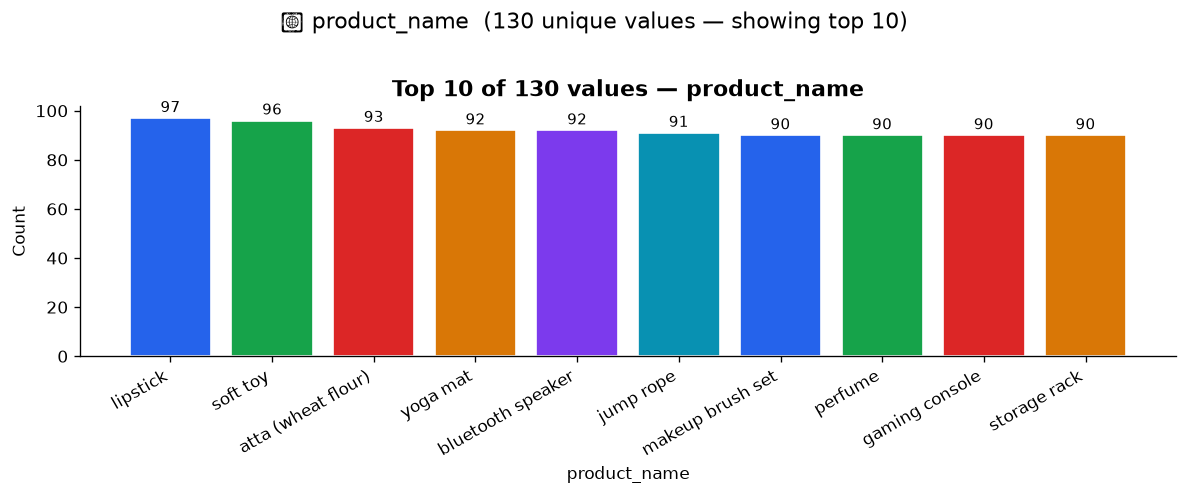


Value counts — product_name  (130 unique):


,count
product_name,
lipstick,97
soft toy,96
atta (wheat flour),93
yoga mat,92
bluetooth speaker,92
...,...
LED TV,62
cricket bat,61
dining table,59


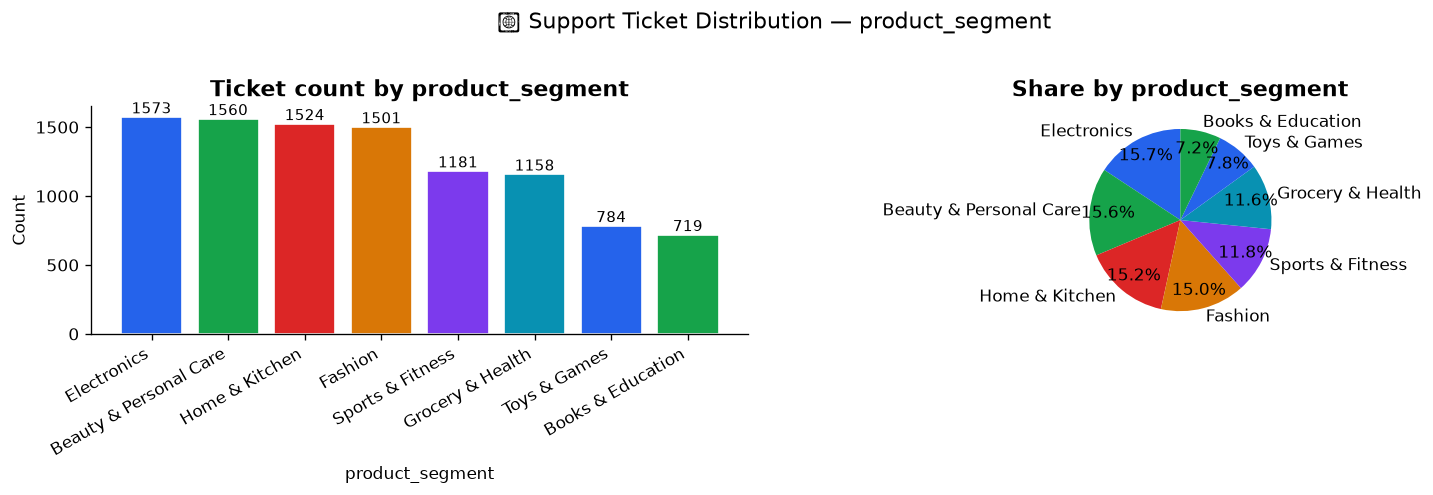


Value counts — product_segment  (8 unique):


,count
product_segment,
Electronics,1573
Beauty & Personal Care,1560
Home & Kitchen,1524
Fashion,1501
Sports & Fitness,1181
Grocery & Health,1158
Toys & Games,784
Books & Education,719


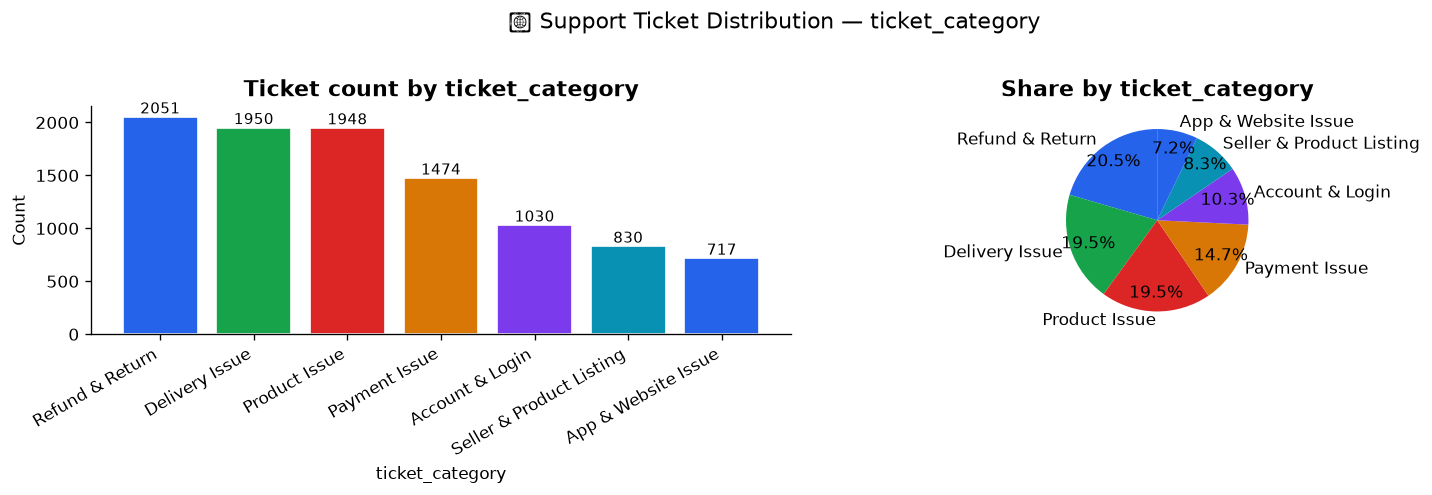


Value counts — ticket_category  (7 unique):


,count
ticket_category,
Refund & Return,2051
Delivery Issue,1950
Product Issue,1948
Payment Issue,1474
Account & Login,1030
Seller & Product Listing,830
App & Website Issue,717


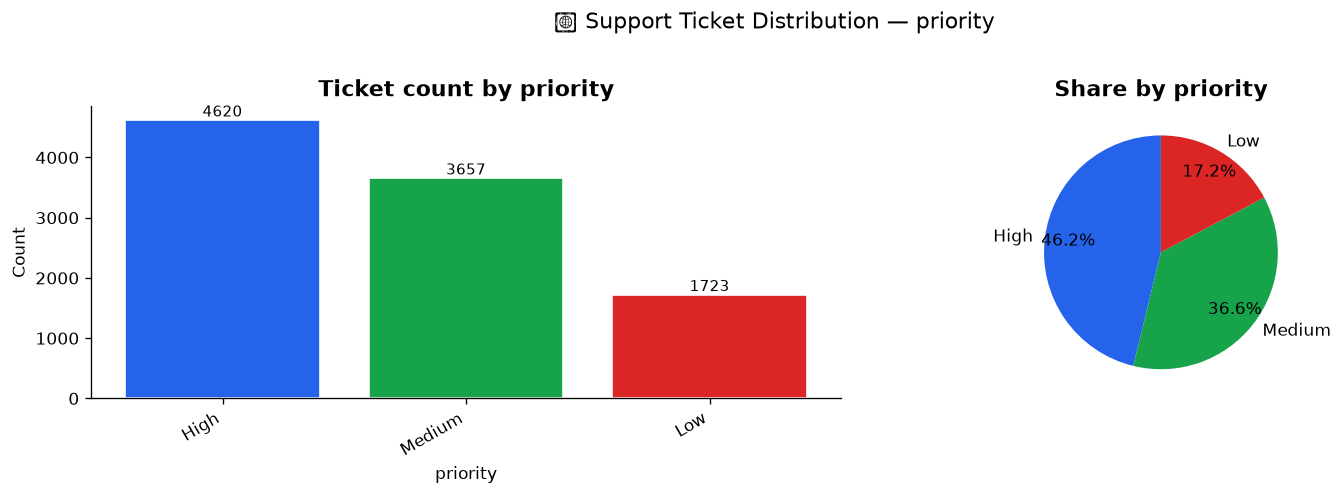


Value counts — priority  (3 unique):


,count
priority,
High,4620
Medium,3657
Low,1723


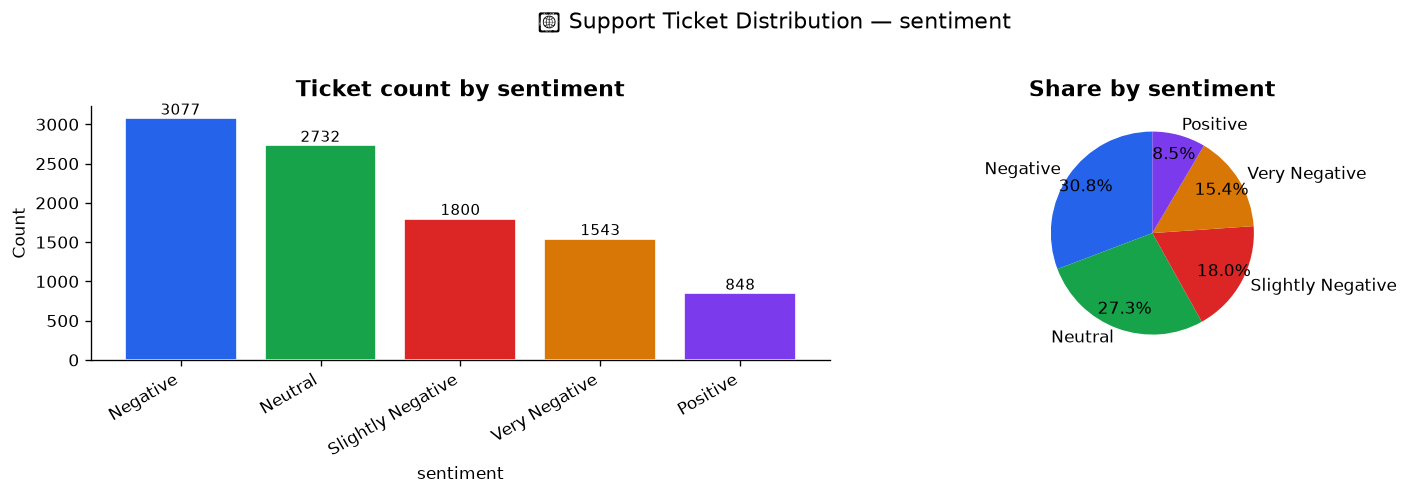


Value counts — sentiment  (5 unique):


,count
sentiment,
Negative,3077
Neutral,2732
Slightly Negative,1800
Very Negative,1543
Positive,848


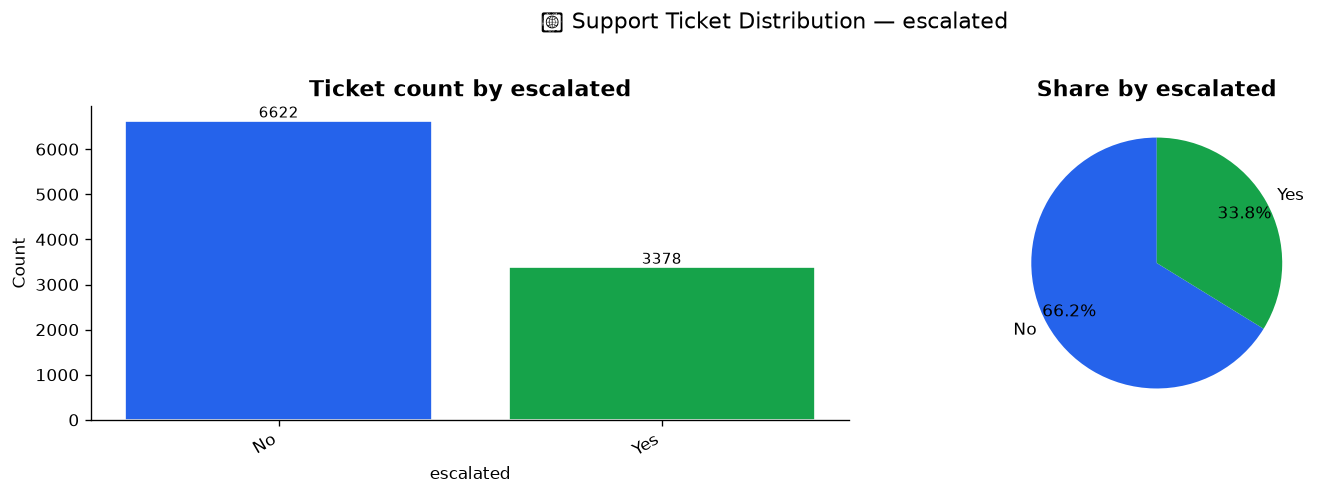


Value counts — escalated  (2 unique):


,count
escalated,
No,6622
Yes,3378


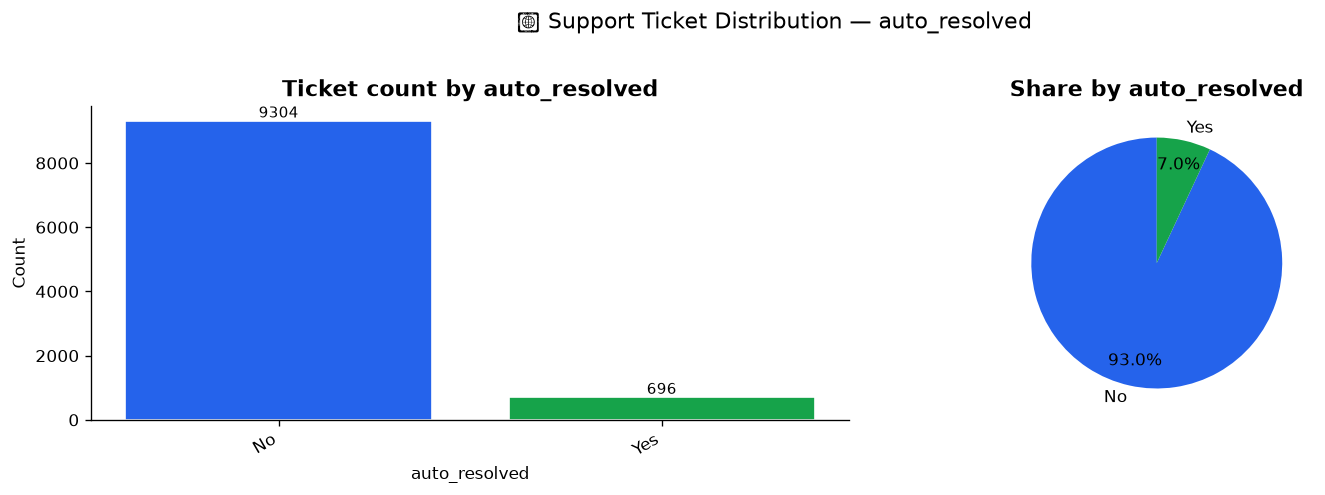


Value counts — auto_resolved  (2 unique):


,count
auto_resolved,
No,9304
Yes,696


In [10]:
# ── Category distribution ─────────────────────────────────────────────────────
def is_categorical(series: pd.Series, max_unique_ratio: float = 0.05) -> bool:
    if isinstance(series.dtype, pd.CategoricalDtype):
        return True
    if not (series.dtype == object or isinstance(series.dtype, pd.StringDtype)):
        return False
    n_unique = series.nunique()
    return n_unique < 50 or (n_unique / len(series)) < max_unique_ratio

cat_cols = [c for c in tickets.columns if is_categorical(tickets[c])]
cat_cols = [c for c in cat_cols if tickets[c].dropna().str.len().mean() < 35]

print(f"Detected {len(cat_cols)} categorical columns: {cat_cols}")

if not cat_cols:
    print("⚠️  No categorical columns detected — check dtype or cardinality thresholds")
else:
    TOP_N = 10          # tune this if needed
    CARDINALITY_LIMIT = 20   # columns with more unique values than this → bar only, no pie

    for cat_col in cat_cols:
        counts = tickets[cat_col].value_counts()
        labels = [str(v) for v in counts.index]
        values = counts.values
        n_unique = len(labels)
        high_cardinality = n_unique > CARDINALITY_LIMIT

        if high_cardinality:
            # ── High cardinality: bar only, top N ────────────────────────────────
            top_labels = labels[:TOP_N]
            top_values = values[:TOP_N]

            fig, ax = plt.subplots(figsize=(10, 4))
            x = range(len(top_labels))
            bars = ax.bar(x, top_values, color=PALETTE[:len(top_values)], edgecolor="white")
            ax.set_xticks(list(x))
            ax.set_xticklabels(top_labels, rotation=30, ha="right")
            ax.set_title(f"Top {TOP_N} of {n_unique} values — {cat_col}")
            ax.set_xlabel(cat_col)
            ax.set_ylabel("Count")
            for bar, val in zip(bars, top_values):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 1, str(val),
                        ha="center", va="bottom", fontsize=9)
            plt.suptitle(f"📋 {cat_col}  ({n_unique} unique values — showing top {TOP_N})",
                        fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

        else:
            # ── Low cardinality: bar + pie side by side ───────────────────────────
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            x = range(len(labels))
            bars = axes[0].bar(x, values, color=PALETTE[:len(values)], edgecolor="white")
            axes[0].set_xticks(list(x))
            axes[0].set_xticklabels(labels, rotation=30, ha="right")
            axes[0].set_title(f"Ticket count by {cat_col}")
            axes[0].set_xlabel(cat_col)
            axes[0].set_ylabel("Count")
            for bar, val in zip(bars, values):
                axes[0].text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 1, str(val),
                            ha="center", va="bottom", fontsize=9)

            axes[1].pie(values, labels=labels,
                        autopct="%1.1f%%", colors=PALETTE[:len(values)],
                        startangle=90, pctdistance=0.8)
            axes[1].set_title(f"Share by {cat_col}")

            plt.suptitle(f"📋 Support Ticket Distribution — {cat_col}", fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

        # Always show full value counts table
        print(f"\nValue counts — {cat_col}  ({n_unique} unique):")
        display(counts.to_frame("count"))

#### 3.7. Query / resolution text length distribution

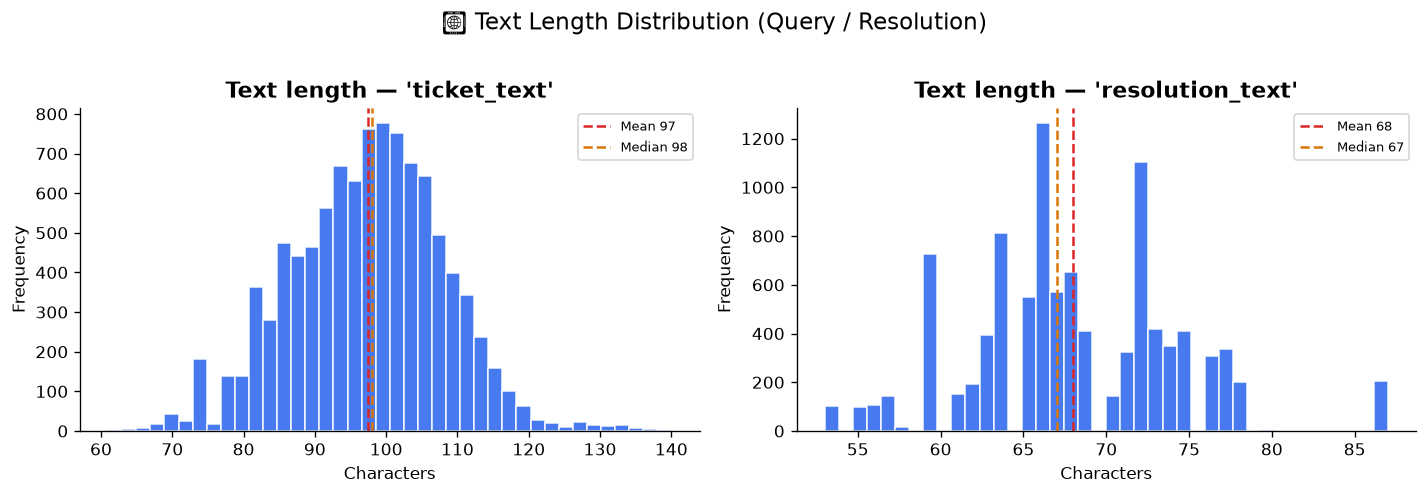

In [11]:
# ── Query / resolution text length distribution ───────────────────────────────
text_cols = [
    c for c in tickets.columns
    if str(tickets[c].dtype) == "str"
    and tickets[c].dropna().str.len().mean() > 45
]

if text_cols:
    fig, axes = plt.subplots(1, len(text_cols), figsize=(6 * len(text_cols), 4))
    if len(text_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, text_cols):
        lengths = tickets[col].dropna().str.len()
        ax.hist(lengths, bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
        ax.axvline(lengths.mean(), color=PALETTE[2], linestyle="--",
                   label=f"Mean {lengths.mean():.0f}")
        ax.axvline(lengths.median(), color=PALETTE[3], linestyle="--",
                   label=f"Median {lengths.median():.0f}")
        ax.set_title(f"Text length — '{col}'")
        ax.set_xlabel("Characters")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=8)
    plt.suptitle("📝 Text Length Distribution (Query / Resolution)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

#### 3.8. Date Analysis

Date range: 2023-01-01 → 2024-12-30
Span: 729 days


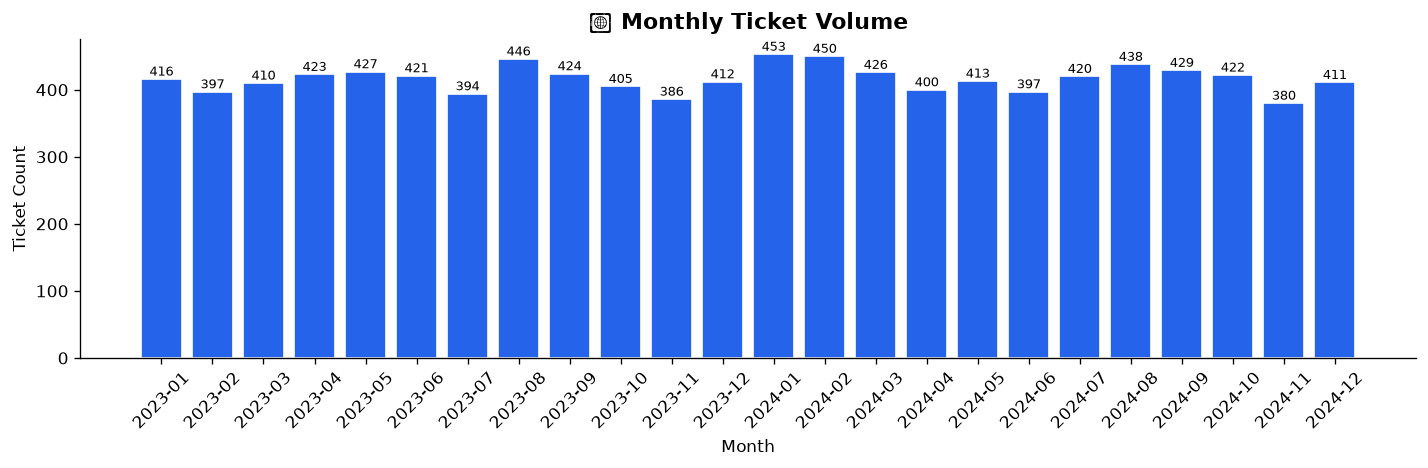

In [12]:
# ── Date analysis ─────────────────────────────────────────────────────────────
tickets["created_date"] = pd.to_datetime(tickets["created_date"], errors="coerce")

print(f"Date range: {tickets['created_date'].min().date()} → {tickets['created_date'].max().date()}")
print(f"Span: {(tickets['created_date'].max() - tickets['created_date'].min()).days} days")

# Monthly ticket volume
tickets["year_month"] = tickets["created_date"].dt.to_period("M")
monthly = tickets.groupby("year_month").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index.astype(str), monthly.values,
       color=PALETTE[0], edgecolor="white")
ax.set_title("📅 Monthly Ticket Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Ticket Count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(ax.patches, monthly.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3, str(val),
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

#### 3.9. Resolution time distribution

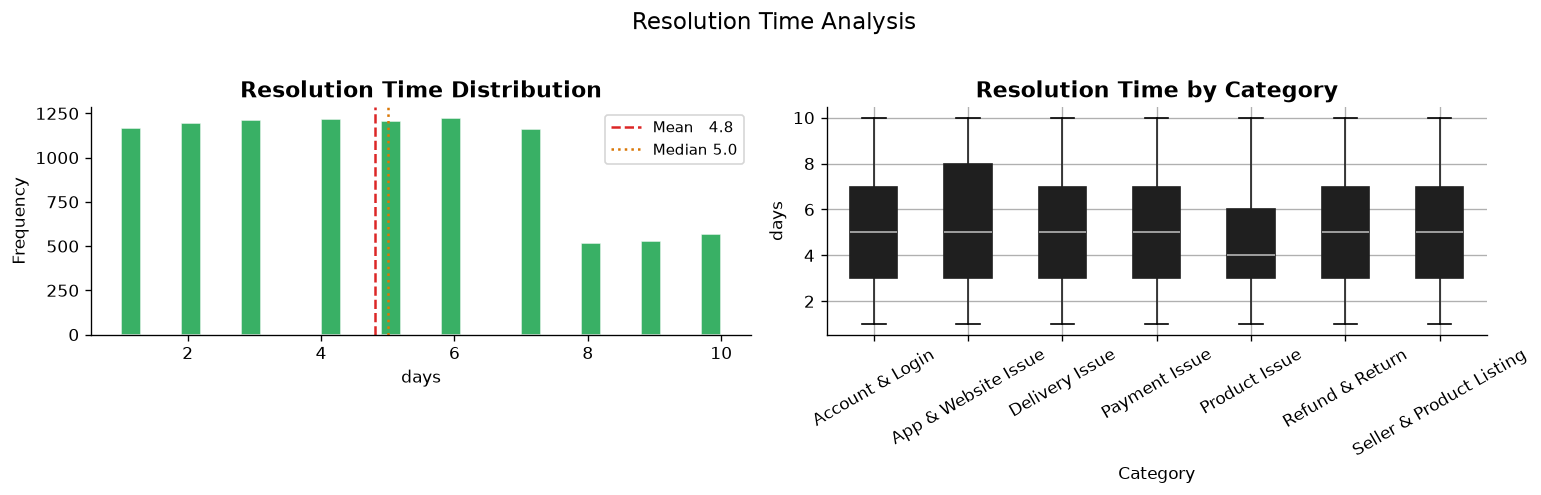


Resolution time stats (days):


,count,mean,std,min,25%,50%,75%,max
resolution_days,10000.0,4.8,2.6,1.0,3.0,5.0,7.0,10.0


In [13]:
# ── Resolution time distribution ──────────────────────────────────────────────
res_time = tickets["resolution_days"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(res_time, bins=30, color=PALETTE[1], edgecolor="white", alpha=0.85)
axes[0].axvline(res_time.mean(),   color=PALETTE[2], linestyle="--",
                label=f"Mean   {res_time.mean():.1f}")
axes[0].axvline(res_time.median(), color=PALETTE[3], linestyle=":",
                label=f"Median {res_time.median():.1f}")
axes[0].set_title("Resolution Time Distribution")
axes[0].set_xlabel("days")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=9)

# Box plot by category
tickets.boxplot(column="resolution_days", by="ticket_category",
                ax=axes[1], patch_artist=True)
axes[1].set_title("Resolution Time by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("days")
axes[1].tick_params(axis="x", rotation=30)
plt.sca(axes[1])
plt.title("Resolution Time by Category")

plt.suptitle("Resolution Time Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nResolution time stats (days):")
display(res_time.describe().rename("resolution_days").to_frame().T.round(1))

#### 3.10. Customer satisfaction distribution

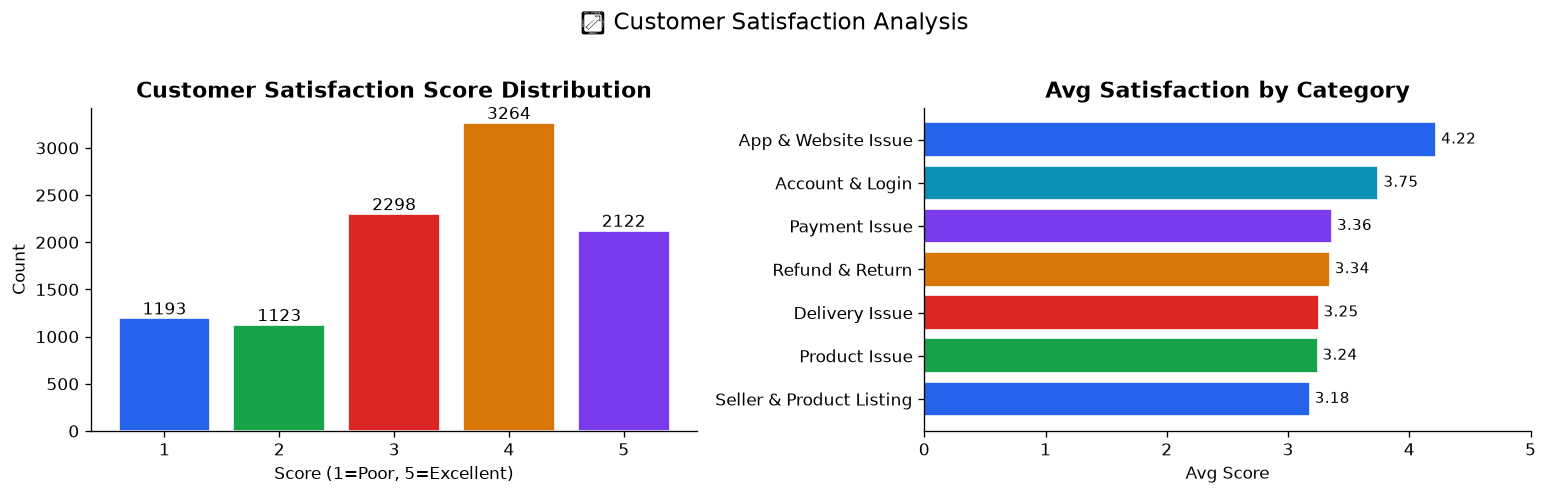


Customer satisfaction stats:


,count,mean,std,min,25%,50%,75%,max
customer_satisfaction,10000.0,3.4,1.27,1.0,3.0,4.0,4.0,5.0


In [14]:
# ── Customer satisfaction distribution ────────────────────────────────────────
sat = tickets["customer_satisfaction_score"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count bar (1–5 scale)
sat_counts = sat.value_counts().sort_index()
bars = axes[0].bar(sat_counts.index.astype(str), sat_counts.values,
                   color=PALETTE[:len(sat_counts)], edgecolor="white")
axes[0].set_title("Customer Satisfaction Score Distribution")
axes[0].set_xlabel("Score (1=Poor, 5=Excellent)")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, sat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, str(val),
                 ha="center", va="bottom", fontsize=10)

# Avg satisfaction by category
sat_cat = tickets.groupby("ticket_category")["customer_satisfaction_score"].mean().sort_values()
bars2 = axes[1].barh(sat_cat.index, sat_cat.values,
                     color=PALETTE[:len(sat_cat)], edgecolor="white")
axes[1].bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)
axes[1].set_xlim(0, 5)
axes[1].set_title("Avg Satisfaction by Category")
axes[1].set_xlabel("Avg Score")

plt.suptitle("⭐ Customer Satisfaction Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nCustomer satisfaction stats:")
display(sat.describe().rename("customer_satisfaction").to_frame().T.round(2))

#### 3.11. Null Map

In [15]:
# ── Null map ─────────────────────────────────────────────────────────────────
plot_nulls(tickets, "Support Tickets")

  ✅ No nulls found in Support Tickets


#### 3.12. resolution_text templating check

In [16]:
section("resolution_text Templating Check")

# 1. Exact duplicate resolution_text across unrelated tickets
exact_dupe_count = tickets['resolution_text'].duplicated().sum()
exact_dupe_pct = round(exact_dupe_count / len(tickets) * 100, 2)
print(f"Exact duplicate resolution_text rows: {exact_dupe_count} ({exact_dupe_pct}%)")

top_repeated = tickets['resolution_text'].value_counts().head(10)
print("\nMost frequently repeated resolution_text values:")
display(top_repeated.to_frame("count"))

# 2. Check whether repeated texts span multiple categories/products (= templated, not coincidental)
if exact_dupe_count > 0:
    most_common_text = top_repeated.index[0]
    spread = tickets[tickets['resolution_text'] == most_common_text]
    print(f"\nMost common resolution_text appears across:")
    print(f"  {spread['ticket_category'].nunique()} categories, {spread['product_name'].nunique()} products")
    display(spread['ticket_category'].value_counts().to_frame("count"))

# 3. Near-duplicate check via normalized text (catches templates with minor variable substitution)
normalized = tickets['resolution_text'].str.lower().str.replace(r'\d+', '', regex=True).str.strip()
near_dupe_count = normalized.duplicated().sum()
print(f"\nNear-duplicate resolution_text (numbers stripped): {near_dupe_count} ({round(near_dupe_count/len(tickets)*100,2)}%)")


  resolution_text Templating Check
Exact duplicate resolution_text rows: 7580 (75.8%)

Most frequently repeated resolution_text values:


,count
resolution_text,
Replacement dispatched without requiring return of defective item.,226
Accidental order refund approved. Amount credited within 2 days.,219
Missing accessory shipped separately at no additional cost.,218
Wrong variant issue confirmed. Correct item dispatched. Return arranged.,215
Partial delivery issue resolved. Missing items shipped separately.,209
Return pickup scheduled for next business day. Refund post quality check.,207
Delivery attempt verified false. Refund or re-shipment offered to customer.,206
Complaint escalated to logistics team. Full refund processed as compensation for delay.,205
Defect acknowledged. Customer given choice of refund or replacement.,203



Most common resolution_text appears across:
  1 categories, 110 products


,count
ticket_category,
Refund & Return,226



Near-duplicate resolution_text (numbers stripped): 9841 (98.41%)


#### 3.13. Curating a Non-Templated Subset for BLEU/ROUGE

In [17]:
section("Curating a Non-Templated Subset for BLEU/ROUGE")

# Frequency of each resolution_text value
text_counts = tickets['resolution_text'].value_counts()

# Candidates: resolution_text values that appear only once (or very rarely) —
# these are far more likely to be genuinely ticket-specific rather than template output
rare_threshold = 2  # appears fewer than this many times
candidate_texts = text_counts[text_counts < rare_threshold].index
candidates = tickets[tickets['resolution_text'].isin(candidate_texts)].copy()

print(f"Candidate rows (resolution_text appears <{rare_threshold}x): {len(candidates)}")
print(f"  ({round(len(candidates)/len(tickets)*100, 2)}% of full dataset)")

# Sanity check: do these actually read as specific/non-templated, or just rare template combos?
display(candidates[['ticket_id', 'ticket_category', 'ticket_text', 'resolution_text']].sample(10, random_state=42))


  Curating a Non-Templated Subset for BLEU/ROUGE
Candidate rows (resolution_text appears <2x): 2301
  (23.01% of full dataset)


,ticket_id,ticket_category,ticket_text,resolution_text
4110,TKT104110,Seller & Product Listing,Bulk order of resistance bands (order #ORD7582...,Seller listing flagged for review. Customer co...
5947,TKT105947,Refund & Return,My face wash return for order #ORD7142398 has ...,Refund of ₹3409 approved and will be credited ...
8723,TKT108723,Product Issue,My LEGO set from order #ORD7941306 appears to ...,Warranty claim initiated. Brand service center...
5502,TKT105502,Delivery Issue,Order #ORD5320387 (vitamin supplements) is stu...,Lost package claim filed. Refund of ₹4923 proc...
1943,TKT101943,Delivery Issue,Delivery was done to a neighbor without my con...,Lost package claim filed. Refund of ₹5269 proc...
3555,TKT103555,Payment Issue,Gift card used for yoga mat order #ORD2655201 ...,Duplicate payment of ₹9133 refunded to origina...
5484,TKT105484,Payment Issue,PhonePe payment for face serum order #ORD35623...,Duplicate payment of ₹8484 refunded to origina...
5824,TKT105824,Seller & Product Listing,Seller is refusing to honor the warranty on my...,Seller listing flagged for review. Customer co...
509,TKT100509,Product Issue,Wrong variant of robot vacuum delivered in ord...,Replacement robot vacuum dispatched after qual...
958,TKT100958,Payment Issue,I can see a pending authorization of ₹7844 for...,Cashback of ₹7844 credited after verification ...


#### 3.14. Curating by Normalized Template Uniqueness

In [18]:
section("Curating by Normalized Template Uniqueness")

# Reuse the normalized column from the templating check (numbers stripped)
normalized = tickets['resolution_text'].str.lower().str.replace(r'\d+', '', regex=True).str.strip()

normalized_counts = normalized.value_counts()
print(f"Distinct normalized templates: {len(normalized_counts)}")
print(f"Templates appearing only once (normalized): {(normalized_counts == 1).sum()}")

# True candidates: rows whose NORMALIZED text is unique in the whole dataset
truly_unique_mask = normalized.map(normalized_counts) == 1
true_candidates = tickets[truly_unique_mask].copy()

print(f"\nTrue non-templated candidates: {len(true_candidates)} ({round(len(true_candidates)/len(tickets)*100,2)}%)")
display(true_candidates[['ticket_id','ticket_category','ticket_text','resolution_text']].sample(min(10,len(true_candidates)), random_state=42))


  Curating by Normalized Template Uniqueness
Distinct normalized templates: 159
Templates appearing only once (normalized): 44

True non-templated candidates: 44 (0.44%)


,ticket_id,ticket_category,ticket_text,resolution_text
8094,TKT108094,Product Issue,The coffee beans in order #ORD1770764 is not c...,Replacement coffee beans dispatched after qual...
5249,TKT105249,Product Issue,Wrong variant of ethnic wear delivered in orde...,Replacement ethnic wear dispatched after quali...
5272,TKT105272,Product Issue,My men's t-shirt (order #ORD1173574) is missin...,Replacement men's t-shirt dispatched after qua...
7645,TKT107645,Product Issue,Screen of my puzzle set (order #ORD4065586) ha...,Replacement puzzle set dispatched after qualit...
6837,TKT106837,Product Issue,My face mask from order #ORD4063289 has develo...,Replacement face mask dispatched after quality...
9651,TKT109651,Product Issue,Product listing for electric toothbrush is com...,Replacement electric toothbrush dispatched aft...
1307,TKT101307,Product Issue,The fitness tracker in order #ORD2701262 is no...,Replacement fitness tracker dispatched after q...
3627,TKT103627,Product Issue,The color of gym wear (order #ORD5502839) is c...,Replacement gym wear dispatched after quality ...
2207,TKT102207,Product Issue,The self-help book I received in order #ORD469...,Replacement self-help book dispatched after qu...
1113,TKT101113,Product Issue,Screen of my study table (order #ORD2416584) h...,Replacement study table dispatched after quali...


#### 3.15. Leakage boundary as an executable assertion

In [19]:
section("Leakage Boundary — Enforced")

FEATURE_COLS = ['ticket_text', 'product_name', 'product_segment']
LEAKAGE_COLS = [
    'confidence_score', 'escalated', 'resolution_text',
    'resolved_date', 'resolution_days', 'auto_resolved',
    'customer_satisfaction_score',
]

overlap = set(FEATURE_COLS) & set(LEAKAGE_COLS)
assert not overlap, f"Leakage columns found in feature set: {overlap}"

print("✅ Leakage assertion passed — no post-resolution column present in FEATURE_COLS.")
print("FEATURE_COLS:", FEATURE_COLS)
print("LEAKAGE_COLS (excluded, post-resolution only):", LEAKAGE_COLS)


  Leakage Boundary — Enforced
✅ Leakage assertion passed — no post-resolution column present in FEATURE_COLS.
FEATURE_COLS: ['ticket_text', 'product_name', 'product_segment']
LEAKAGE_COLS (excluded, post-resolution only): ['confidence_score', 'escalated', 'resolution_text', 'resolved_date', 'resolution_days', 'auto_resolved', 'customer_satisfaction_score']


 ## 4.FAQ_Knowledge_Base

#### 4.1. Profile — FAQ Knowledge Base 

In [20]:
faq_df = pd.read_csv(FAQ_KNOWLEDGE_BASE_PATH)
_ = quick_profile(faq_df, "FAQ Knowledge Base")



  Profile — FAQ Knowledge Base  (150 rows × 4 cols)


,dtype,non_null,null_count,null_pct,unique,sample_values
column,,,,,,
faq_id,str,150,0,0.0,150,"['FAQ001', 'FAQ002', 'FAQ003']"
question,str,150,0,0.0,150,"['How do I track my order?', 'What should I do..."
answer,str,150,0,0.0,150,['Go to My Orders > Select Order > Track Packa...
category,str,150,0,0.0,7,"['Delivery Issue', 'Refund & Return', 'Payment..."


#### 4.2. Cardinality Check

In [21]:

_ = cardinality_report(faq_df, "FAQ Knowledge Base")


  Cardinality Report — FAQ Knowledge Base


,unique,unique_ratio,cardinality
column,,,
faq_id,150,1.000,HIGH (likely free-text/ID)
question,150,1.000,HIGH (likely free-text/ID)
answer,150,1.000,HIGH (likely free-text/ID)
category,7,0.047,LOW (categorical)


#### 4.3. FAQ text length analysis

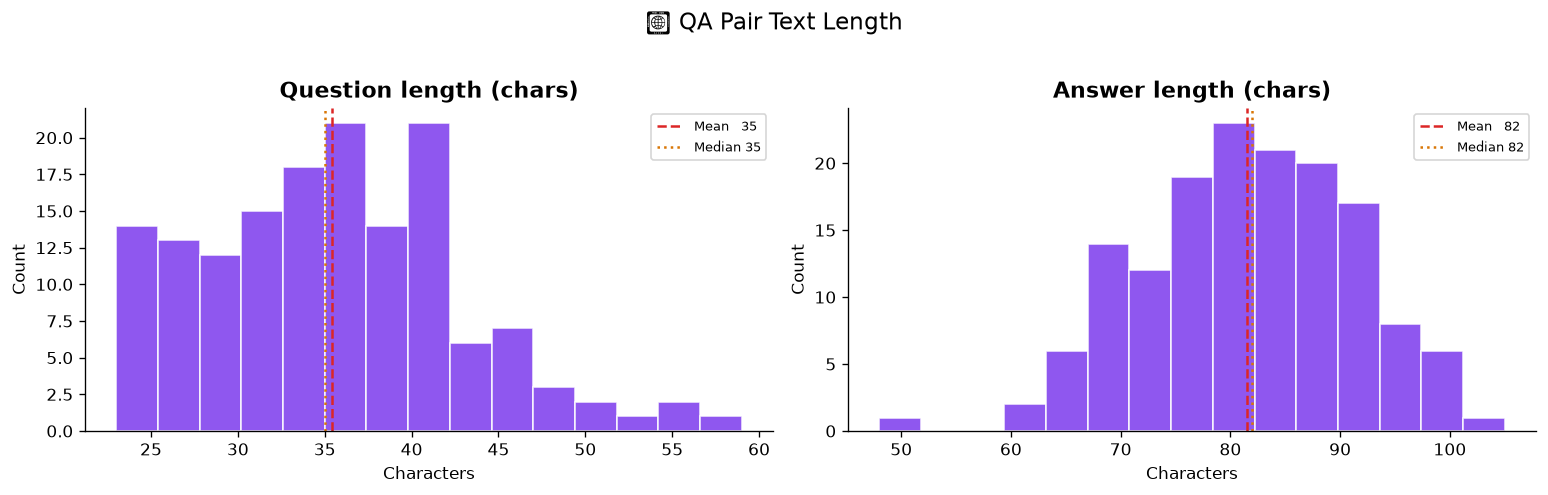


Text length stats:


,count,mean,std,min,25%,50%,75%,max
question,150.0,35.4,7.4,23.0,30.0,35.0,40.0,59.0
answer,150.0,81.5,9.6,48.0,75.0,82.0,88.0,105.0


In [22]:
# ── FAQ text length analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(axes, ["question", "answer"], ["Question", "Answer"]):
    lengths = faq_df[col].dropna().str.len()
    ax.hist(lengths, bins=15, color=PALETTE[4], edgecolor="white", alpha=0.85)
    ax.axvline(lengths.mean(),   color=PALETTE[2], linestyle="--",
               label=f"Mean   {lengths.mean():.0f}")
    ax.axvline(lengths.median(), color=PALETTE[3], linestyle=":",
               label=f"Median {lengths.median():.0f}")
    ax.set_title(f"{label} length (chars)")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("📖 QA Pair Text Length", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nText length stats:")
display(faq_df[["question", "answer"]].apply(lambda c: c.str.len().describe()).T.round(1))

Detected 1 categorical columns: ['category']


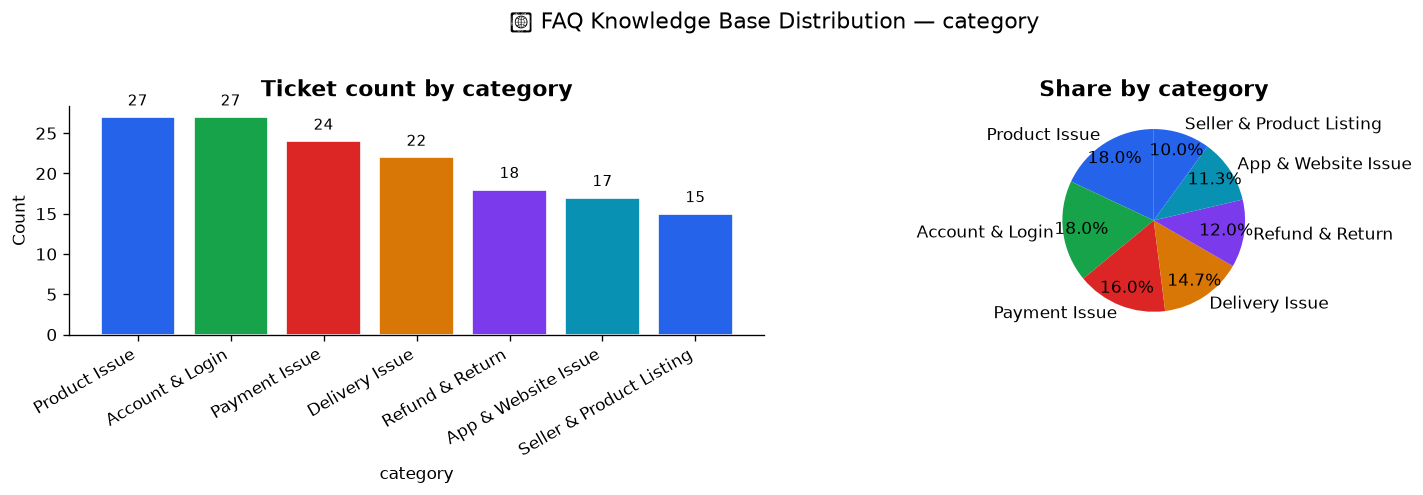


Value counts — category  (7 unique):


,count
category,
Product Issue,27
Account & Login,27
Payment Issue,24
Delivery Issue,22
Refund & Return,18
App & Website Issue,17
Seller & Product Listing,15


In [23]:
cat_cols = [c for c in faq_df.columns if is_categorical(faq_df[c])]
cat_cols = [c for c in cat_cols if faq_df[c].dropna().str.len().mean() < 35]

print(f"Detected {len(cat_cols)} categorical columns: {cat_cols}")

if not cat_cols:
    print("⚠️  No categorical columns detected — check dtype or cardinality thresholds")
else:
    TOP_N = 10          # tune this if needed
    CARDINALITY_LIMIT = 20   # columns with more unique values than this → bar only, no pie

    for cat_col in cat_cols:
        counts = faq_df[cat_col].value_counts()
        labels = [str(v) for v in counts.index]
        values = counts.values
        n_unique = len(labels)
        high_cardinality = n_unique > CARDINALITY_LIMIT

        if high_cardinality:
            # ── High cardinality: bar only, top N ────────────────────────────────
            top_labels = labels[:TOP_N]
            top_values = values[:TOP_N]

            fig, ax = plt.subplots(figsize=(10, 4))
            x = range(len(top_labels))
            bars = ax.bar(x, top_values, color=PALETTE[:len(top_values)], edgecolor="white")
            ax.set_xticks(list(x))
            ax.set_xticklabels(top_labels, rotation=30, ha="right")
            ax.set_title(f"Top {TOP_N} of {n_unique} values — {cat_col}")
            ax.set_xlabel(cat_col)
            ax.set_ylabel("Count")
            for bar, val in zip(bars, top_values):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 1, str(val),
                        ha="center", va="bottom", fontsize=9)
            plt.suptitle(f"📋 {cat_col}  ({n_unique} unique values — showing top {TOP_N})",
                        fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

        else:
            # ── Low cardinality: bar + pie side by side ───────────────────────────
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            x = range(len(labels))
            bars = axes[0].bar(x, values, color=PALETTE[:len(values)], edgecolor="white")
            axes[0].set_xticks(list(x))
            axes[0].set_xticklabels(labels, rotation=30, ha="right")
            axes[0].set_title(f"Ticket count by {cat_col}")
            axes[0].set_xlabel(cat_col)
            axes[0].set_ylabel("Count")
            for bar, val in zip(bars, values):
                axes[0].text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 1, str(val),
                            ha="center", va="bottom", fontsize=9)

            axes[1].pie(values, labels=labels,
                        autopct="%1.1f%%", colors=PALETTE[:len(values)],
                        startangle=90, pctdistance=0.8)
            axes[1].set_title(f"Share by {cat_col}")

            plt.suptitle(f"📋 FAQ Knowledge Base Distribution — {cat_col}", fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()

        # Always show full value counts table
        print(f"\nValue counts — {cat_col}  ({n_unique} unique):")
        display(counts.to_frame("count"))

## Phase 1 Summary — Data Profiling

**Support Tickets (10,000 rows × 15 cols)**
- No nulls; dtypes as expected
- **Duplicates:** 0 full-row, 0 duplicate `ticket_id`; 1,223 duplicate `ticket_text` (likely genuinely common complaints — kept, not deduped)
- **Label consistency within duplicated `ticket_text` (key finding):** `ticket_category` 100% consistent (224/224 groups) — text alone deterministically implies category. `priority` mostly consistent (165/224, 73.7%). `sentiment` largely inconsistent (only 71/224 groups, 31.7%) — identical wording carries different sentiment labels most of the time, concentrated in the *highest-frequency* templates (54–70 occurrences each), not a long tail. This sets a hard accuracy ceiling on the Sentiment classifier independent of model quality.
- **Cardinality:** categoricals clean (`ticket_category`=7, `priority`=3, `sentiment`=5, `escalated`/`auto_resolved`=2); `product_name`=130, `resolution_text`=2,420 medium; `ticket_id`/`ticket_text` high as expected
- **Dates:** fully clean — 0 unparseable, 0 inverted (`resolved_date < created_date`), 0 mismatches vs. computed `resolution_days`. Range: created Jan 2023–Dec 2024, resolved through Jan 2025
- **`resolution_text` templating (key finding):** 75.8% exact duplicates, 98.41% near-duplicates after stripping digits, only **159 distinct normalized templates** total (0.44% pass strict uniqueness) → confirmed fully template-generated, not ticket-specific
- **Leakage boundary:** `confidence_score`, `escalated`, `resolution_text`, `resolved_date`, `resolution_days`, `auto_resolved`, `customer_satisfaction_score` are post-resolution only — excluded from features. **Now enforced as a code assertion**, not just conceptually verified.

**FAQ Knowledge Base (150 rows × 4 cols)**
- No nulls; `faq_id`/`question`/`answer` 100% unique as expected; `category` cleanly matches the 7 ticket categories

**Downstream impact**
- Phase 5 BLEU/ROUGE **retained** (required deliverable) — reported alongside LLM-as-judge, not instead of it. Computed on full test set and again on the subset excluding template-duplicate `resolution_text` rows, given the 75.8% exact-duplicate finding above. LLM-as-judge PASS/FAIL remains the primary/authoritative response-quality signal; BLEU/ROUGE is a required secondary metric reported with this limitation stated explicitly.
- Category/Priority/Sentiment modeling proceeds safely on `ticket_text`, `product_name`, `product_segment` only — but expect Sentiment's ceiling to be meaningfully lower than Category's given the label-consistency finding above.

